# Bodrum Hotel & Destination Intelligence
## 13 - Google Travel All-Hotels Review EDA

In [1]:

import pandas as pd
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
%matplotlib inline
import os

REPO_ROOT = r"C:\Users\bilin\OneDrive\Masaüstü\bodrum\hotelrewiews\hotel-reviews"
FIG_DIR = REPO_ROOT + r"\reports\figures\google_travel_all_hotels_eda"
os.makedirs(FIG_DIR, exist_ok=True)
pd.set_option("display.max_columns", 50)

clean = pd.read_csv(REPO_ROOT + r"\data\processed\google_travel_all_hotels_reviews_clean.csv")
print("rows:", len(clean), "hotels:", clean['hotel_id'].nunique())
clean.head(2)


rows: 2336 hotels: 104


,hotel_id,hotel_name,area,review_text,review_text_clean,review_details_raw,review_date_raw,review_date_is_approximate,review_age_days_approx,is_edited,review_rating_raw,review_rating_numeric,rating_group,review_source,rooms_score,service_score,location_score,review_word_count,review_char_count,language_detected,review_hash,source_url,collected_at,quality_flags
0,BOD001,Aksoy Taş Ev,Akyarlar,7 gece kaldığımız aksoy taşevden memnun ayrıld...,7 gece kaldığımız aksoy taşevden memnun ayrıld...,"Odalar4,0Hizmet5,0Konum5,0\nOtelde öne çıkanla...",Google üzerinde bir ay önce,True,30,False,5/5,5.0,HIGH,GOOGLE,4.0,5.0,5.0,114,957,tr,a90353377c98ca65ac2b7b63fb03324c90387e342d09e2...,https://www.google.com/travel/hotels/entity/Ch...,2026-08-26T14:06:02Z,NaN
1,BOD001,Aksoy Taş Ev,Akyarlar,"10 gün konakladık. Temiz, kaliteli, denize sıf...","10 gün konakladık. Temiz, kaliteli, denize sıf...","Odalar5,0Hizmet5,0Konum5,0",Google üzerinde bir ay önce,True,30,False,5/5,5.0,HIGH,GOOGLE,5.0,5.0,5.0,33,240,tr,01ca23a873d2f76dd3f9f983bdaace6f3e2c6907c50de9...,https://www.google.com/travel/hotels/entity/Ch...,2026-08-26T14:06:02Z,NaN


## C2: Overall KPI

In [2]:

kpi = {
    "total_reviews": len(clean),
    "hotel_count": clean["hotel_id"].nunique(),
    "area_count": clean["area"].nunique(),
    "mean_rating": round(clean["review_rating_numeric"].mean(), 2),
    "median_rating": clean["review_rating_numeric"].median(),
    "low_rating_share_pct": round((clean["rating_group"]=="LOW").mean()*100, 1),
    "high_rating_share_pct": round((clean["rating_group"]=="HIGH").mean()*100, 1),
    "details_coverage_pct": round(clean["rooms_score"].notna().mean()*100, 1),
    "google_source_share_pct": round((clean["review_source"]=="GOOGLE").mean()*100, 1),
}
for k, v in kpi.items():
    print(f"{k}: {v}")


total_reviews: 2336
hotel_count: 104
area_count: 14
mean_rating: 4.13
median_rating: 5.0
low_rating_share_pct: 17.4
high_rating_share_pct: 76.4
details_coverage_pct: 64.8
google_source_share_pct: 89.4


## C4-C5: Hotel rating summary + sample support tiers

In [3]:

def support_tier(n):
    if n < 5: return "VERY_LOW_SUPPORT"
    if n < 20: return "LOW_SUPPORT"
    if n < 50: return "MODERATE"
    return "STRONGER"

hotel_rating = clean.groupby(["hotel_id", "hotel_name", "area"]).agg(
    n=("review_rating_numeric", "count"),
    mean_rating=("review_rating_numeric", "mean"),
    median_rating=("review_rating_numeric", "median"),
    std=("review_rating_numeric", "std"),
    q25=("review_rating_numeric", lambda s: s.quantile(0.25)),
    q75=("review_rating_numeric", lambda s: s.quantile(0.75)),
).reset_index()
low = clean[clean["rating_group"]=="LOW"].groupby("hotel_id").size()
mid = clean[clean["rating_group"]=="MID"].groupby("hotel_id").size()
high = clean[clean["rating_group"]=="HIGH"].groupby("hotel_id").size()
hotel_rating = hotel_rating.set_index("hotel_id")
hotel_rating["low_share"] = (low / hotel_rating["n"]).fillna(0).round(3)
hotel_rating["mid_share"] = (mid / hotel_rating["n"]).fillna(0).round(3)
hotel_rating["high_share"] = (high / hotel_rating["n"]).fillna(0).round(3)
hotel_rating["sample_support"] = hotel_rating["n"].apply(support_tier)
hotel_rating = hotel_rating.reset_index()
hotel_rating.to_csv(REPO_ROOT + r"\reports\google_travel_all_hotels_rating_summary.csv", index=False)
hotel_rating["sample_support"].value_counts()


sample_support
LOW_SUPPORT    55
MODERATE       38
STRONGER       11
Name: count, dtype: int64

## C6-C7: Normalized rating distribution (supported hotels only)

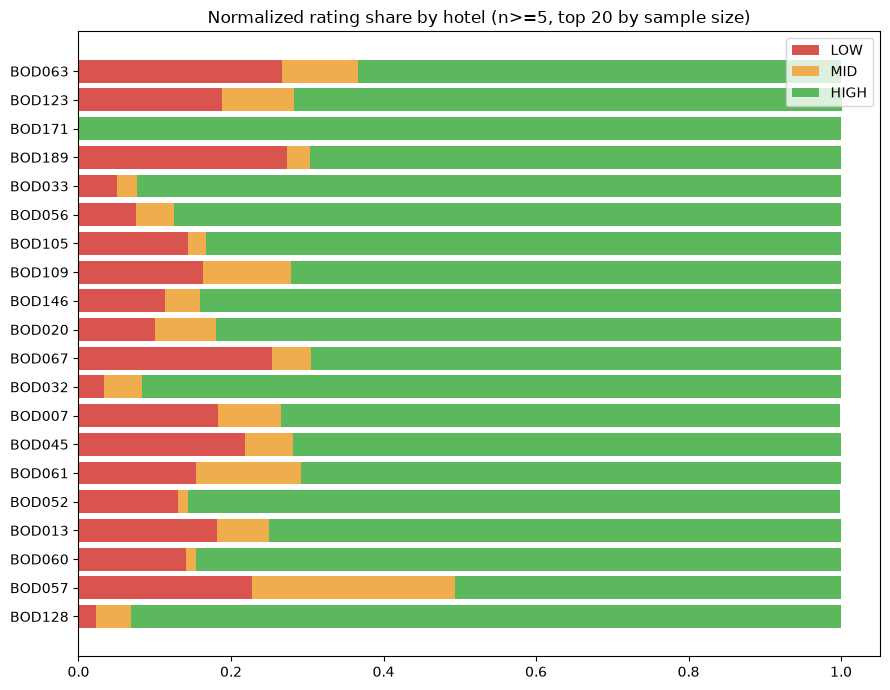

In [4]:

supported = hotel_rating[hotel_rating["n"] >= 5].sort_values("n", ascending=False).head(20)
if len(supported):
    fig, ax = plt.subplots(figsize=(9, max(4, 0.35*len(supported))))
    ax.barh(supported["hotel_id"], supported["low_share"], color="#d9534f", label="LOW")
    ax.barh(supported["hotel_id"], supported["mid_share"], left=supported["low_share"], color="#f0ad4e", label="MID")
    ax.barh(supported["hotel_id"], supported["high_share"],
            left=supported["low_share"]+supported["mid_share"], color="#5cb85c", label="HIGH")
    ax.set_title("Normalized rating share by hotel (n>=5, top 20 by sample size)")
    ax.legend()
    plt.tight_layout()
    plt.savefig(FIG_DIR + r"\normalized_rating_distribution.png", dpi=110)
    plt.show()
else:
    print("No hotel with n>=5 yet - skipping this chart.")


### Grafik nasıl okunur?
Her satır bir oteli temsil eder; çubuk toplamı %100'dür, renkler LOW/MID/HIGH pay yüzdesidir.
### Ne görüyoruz?
Ham sayı yerine ORAN kullanıldığı için oteller adil biçimde karşılaştırılabilir.
### Neden önemli?
Az örneklemli bir otelin tesadüfen yüksek/düşük çıkması ile gerçek eğilim ayrıştırılır.
### Dikkat edilmesi gereken nokta
Yalnızca n>=5 olan oteller gösterilmiştir; daha küçük örneklemler yorumlanmamalıdır.

## C8: Area-level rating summary

In [5]:

area_summary = clean.groupby("area").agg(
    hotel_count_with_reviews=("hotel_id", "nunique"),
    review_count=("hotel_id", "size"),
    review_weighted_mean_rating=("review_rating_numeric", "mean"),
).reset_index()
med_by_hotel = hotel_rating.groupby("area")["median_rating"].median().rename("median_hotel_rating")
area_summary = area_summary.merge(med_by_hotel, on="area", how="left")
low_by_area = hotel_rating.groupby("area")["low_share"].median().rename("median_low_share")
high_by_area = hotel_rating.groupby("area")["high_share"].median().rename("median_high_share")
area_summary = area_summary.merge(low_by_area, on="area").merge(high_by_area, on="area")
area_summary = area_summary.sort_values("review_count", ascending=False)
area_summary.to_csv(REPO_ROOT + r"\reports\google_travel_all_hotels_area_summary.csv", index=False)
area_summary.head(10)


,area,hotel_count_with_reviews,review_count,review_weighted_mean_rating,median_hotel_rating,median_low_share,median_high_share
4,Gümbet,11,367,3.967847,5.0,0.200,0.7000
9,Ortakent-Yahşi,15,320,4.309375,5.0,0.172,0.7590
0,Akyarlar,14,300,4.190000,5.0,0.157,0.8000
3,Göltürkbükü,8,266,4.139623,5.0,0.100,0.8660
1,Bitez,9,210,4.200957,5.0,0.200,0.8000
10,Torba,11,193,4.300518,5.0,0.100,0.8500
7,Güvercinlik,8,183,3.775956,5.0,0.198,0.7000
6,Gündoğan,8,120,4.433333,5.0,0.100,0.9000
5,Gümüşlük,6,104,3.846154,5.0,0.227,0.7345
13,Yalıkavak,4,96,4.442708,5.0,0.100,0.9000


## C9: Review length vs rating

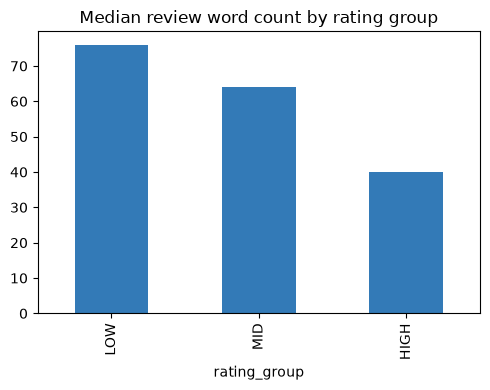

Spearman(rating, word_count) = -0.224 (exploratory, not causal)


In [6]:

by_group = clean.groupby("rating_group")["review_word_count"].median()
fig, ax = plt.subplots(figsize=(5,4))
by_group.reindex(["LOW","MID","HIGH"]).plot(kind="bar", ax=ax, color="#337ab7")
ax.set_title("Median review word count by rating group")
plt.tight_layout()
plt.savefig(FIG_DIR + r"\review_length_vs_rating.png", dpi=110)
plt.show()

valid = clean.dropna(subset=["review_rating_numeric", "review_word_count"])
if len(valid) > 5:
    corr = valid["review_rating_numeric"].corr(valid["review_word_count"], method="spearman")
    print("Spearman(rating, word_count) =", round(corr, 3), "(exploratory, not causal)")


## C10-C11: Source distribution & Google-only sensitivity

In [7]:

overall_mean = clean["review_rating_numeric"].mean()
google_only = clean[clean["review_source"]=="GOOGLE"]
google_only_mean = google_only["review_rating_numeric"].mean()
sensitivity = pd.DataFrame([{
    "all_sources_mean_rating": round(overall_mean, 3),
    "google_only_mean_rating": round(google_only_mean, 3),
    "all_sources_n": len(clean),
    "google_only_n": len(google_only),
    "difference": round(overall_mean - google_only_mean, 3),
}])
sensitivity.to_csv(REPO_ROOT + r"\reports\google_travel_all_hotels_google_only_sensitivity.csv", index=False)
sensitivity


,all_sources_mean_rating,google_only_mean_rating,all_sources_n,google_only_n,difference
0,4.128,4.105,2336,2088,0.023


## C12: Details (rooms/service/location) score analysis

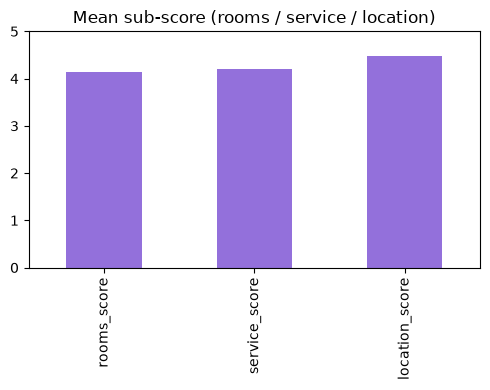

,count,mean,median,coverage_pct
rooms_score,1514.0,4.140687,5.0,64.8
service_score,1514.0,4.195509,5.0,64.8
location_score,1514.0,4.487450,5.0,64.8


In [8]:

detail_summary = clean[["rooms_score","service_score","location_score"]].agg(["count","mean","median"]).T
detail_summary["coverage_pct"] = (detail_summary["count"] / len(clean) * 100).round(1)
detail_summary.to_csv(REPO_ROOT + r"\reports\google_travel_all_hotels_detail_score_summary.csv")

fig, ax = plt.subplots(figsize=(5,4))
detail_summary["mean"].plot(kind="bar", ax=ax, color="#9370db")
ax.set_title("Mean sub-score (rooms / service / location)")
ax.set_ylim(0,5)
plt.tight_layout()
plt.savefig(FIG_DIR + r"\detail_score_means.png", dpi=110)
plt.show()
detail_summary


## C14: Main rating vs details correlation (exploratory)

In [9]:

corr_rows = []
for col in ["rooms_score","service_score","location_score"]:
    sub = clean.dropna(subset=["review_rating_numeric", col])
    if len(sub) > 5:
        corr_rows.append({"detail": col, "spearman_vs_main_rating": round(
            sub["review_rating_numeric"].corr(sub[col], method="spearman"), 3), "n": len(sub)})
corr_df = pd.DataFrame(corr_rows)
corr_df.to_csv(REPO_ROOT + r"\reports\google_travel_all_hotels_detail_score_correlations.csv", index=False)
corr_df


,detail,spearman_vs_main_rating,n
0,rooms_score,0.833,1514
1,service_score,0.876,1514
2,location_score,0.737,1514


## C17: Hotel profile table

In [10]:

word_median = clean.groupby("hotel_id")["review_word_count"].median().rename("median_word_count")
details_cov = clean.groupby("hotel_id")["rooms_score"].apply(lambda s: round(s.notna().mean()*100,1)).rename("details_coverage_pct")
google_share = clean.groupby("hotel_id")["review_source"].apply(lambda s: round((s=="GOOGLE").mean()*100,1)).rename("google_source_share_pct")

profile = hotel_rating.set_index("hotel_id").join([word_median, details_cov, google_share]).reset_index()
profile = profile.rename(columns={"n": "n_reviews"})
profile = profile[["hotel_id","hotel_name","area","n_reviews","mean_rating","median_rating",
                    "low_share","high_share","median_word_count","details_coverage_pct",
                    "google_source_share_pct","sample_support"]]
profile.to_csv(REPO_ROOT + r"\reports\google_travel_all_hotels_profile_summary.csv", index=False)
profile.sort_values("n_reviews", ascending=False).head(10)


,hotel_id,hotel_name,area,n_reviews,mean_rating,median_rating,low_share,high_share,median_word_count,details_coverage_pct,google_source_share_pct,sample_support
75,BOD128,Lugga Boutique Hotel & Beach,Ortakent-Yahşi,87,4.781609,5.0,0.023,0.931,38.0,71.3,89.7,STRONGER
33,BOD057,Selvi Bodrum,Göltürkbükü,79,3.506329,4.0,0.228,0.506,38.5,36.2,92.5,STRONGER
35,BOD060,Club Shark Hotel,Gümbet,78,4.307692,5.0,0.141,0.846,38.5,65.4,93.6,STRONGER
11,BOD013,"Sentido Bellazure - Akyarlar, Bodrum / Turkey",Akyarlar,72,4.027778,5.0,0.181,0.750,46.5,52.8,91.7,STRONGER
29,BOD052,Flamm Bodrum,Göltürkbükü,69,4.463768,5.0,0.130,0.855,38.0,44.9,92.8,STRONGER
36,BOD061,Gümbet Anıl Beach,Gümbet,65,4.000000,5.0,0.154,0.708,39.0,69.2,95.4,STRONGER
25,BOD045,Salmakis Resort & Spa,Bodrum Merkez,64,3.859375,4.5,0.219,0.719,48.0,48.4,93.8,STRONGER
6,BOD007,Kefaluka Resort,Akyarlar,60,4.066667,5.0,0.183,0.733,79.0,90.0,98.3,STRONGER
20,BOD032,Paloma Family Club Bitez,Bitez,60,4.583333,5.0,0.033,0.917,44.0,60.0,91.7,STRONGER
41,BOD067,Sami Beach Hotel,Gümbet,59,3.813559,5.0,0.254,0.695,42.0,55.9,93.2,STRONGER


## C21: Notebook 13 - Key Findings

In [11]:

findings = []
findings.append(f"Corpus covers {clean['hotel_id'].nunique()} hotels across {clean['area'].nunique()} areas, {len(clean)} reviews total.")
findings.append(f"Sample support: {(hotel_rating['sample_support']=='VERY_LOW_SUPPORT').sum()} hotels VERY_LOW_SUPPORT (n<5) - "
                 f"their rating shares should not be over-interpreted.")
top_high = hotel_rating[hotel_rating['n']>=5].sort_values('high_share', ascending=False).head(3)
findings.append("Highest supported HIGH-rating-share hotels (n>=5): " + ", ".join(top_high['hotel_id'].tolist()) if len(top_high) else "No hotel yet clears n>=5.")
top_low = hotel_rating[hotel_rating['n']>=5].sort_values('low_share', ascending=False).head(3)
findings.append("Highest supported LOW-rating-share hotels (n>=5): " + ", ".join(top_low['hotel_id'].tolist()) if len(top_low) else "No hotel yet clears n>=5.")
findings.append(f"Google-only sensitivity: overall mean {round(overall_mean,2)} vs Google-only mean {round(google_only_mean,2)} "
                 f"(difference {round(overall_mean-google_only_mean,3)}).")
findings.append(f"Area with most review coverage: {area_summary.iloc[0]['area']} ({int(area_summary.iloc[0]['review_count'])} reviews).")
findings.append("Raw review counts are heavily hotel-imbalanced (see notebook 12) - all comparisons above use rates/shares, not raw counts.")
for i, f_ in enumerate(findings, 1):
    print(f"{i}. {f_}")


1. Corpus covers 104 hotels across 14 areas, 2336 reviews total.
2. Sample support: 0 hotels VERY_LOW_SUPPORT (n<5) - their rating shares should not be over-interpreted.
3. Highest supported HIGH-rating-share hotels (n>=5): BOD001, BOD008, BOD026
4. Highest supported LOW-rating-share hotels (n>=5): BOD161, BOD077, BOD104
5. Google-only sensitivity: overall mean 4.13 vs Google-only mean 4.11 (difference 0.023).
6. Area with most review coverage: Gümbet (367 reviews).
7. Raw review counts are heavily hotel-imbalanced (see notebook 12) - all comparisons above use rates/shares, not raw counts.
